# Notebook 2

### Author: Santiago Amaya Zapata

### Capture nonlinear and interaction effects using polynomial feature engineering and an explicit bias term:

L_hat = X @ w + b.

## 1. Imports and dataset

In this notebook we extend the linear regression model by introducing polynomial and interaction features.
Instead of assuming a purely linear relationship, we explicitly engineer nonlinear terms that allow the model to capture more complex physical dependencies.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
T = np.array([3800, 4400, 5800, 6400, 6900, 7400, 7900, 8300, 8800, 9200])
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

n = len(M)

## 2. Dataset visualization (L vs M with temperature encoding)

Before training a more complex model, we visualize the data to understand the joint influence of mass and temperature on luminosity.

Stellar temperature is encoded using color, allowing us to visually inspect whether stars with similar mass but different temperatures exhibit different luminosities.

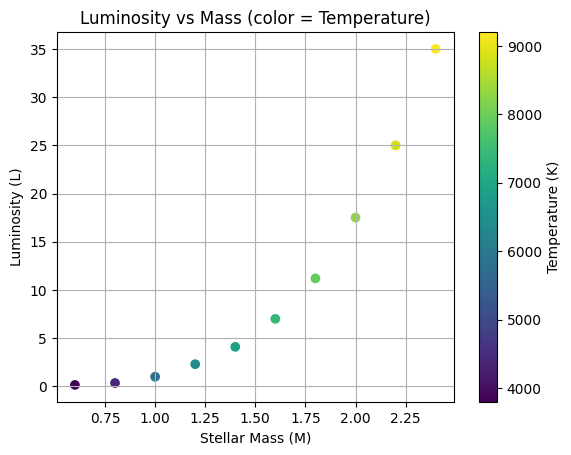

In [3]:
plt.figure()
sc = plt.scatter(M, L, c=T)
plt.xlabel("Stellar Mass (M)")
plt.ylabel("Luminosity (L)")
plt.title("Luminosity vs Mass (color = Temperature)")
plt.colorbar(sc, label="Temperature (K)")
plt.grid(True)
plt.show()


## 3. Feature engineering: design matrix X

Instead of fitting a nonlinear model directly, we transform the input variables into a higher-dimensional feature space.

This approach allows us to keep the model linear in the parameters while capturing nonlinear physical effects.

The interaction term 𝑀 ⋅ 𝑇 models the idea that the effect of mass on luminosity may depend on stellar temperature.

In [4]:
def build_features(M, T):
    X = np.column_stack([
        M,
        T,
        M**2,
        M * T
    ])
    return X

X = build_features(M, T)


## 4. Model definition and loss function

The hypothesis function is defined as a linear combination of engineered features plus a bias term.

Although the model is linear in parameters, it is nonlinear with respect to the original physical variables.

Mean Squared Error (MSE) is used as the loss function because it penalizes large deviations more strongly and is differentiable.

In [5]:
def predict(X, w, b):
    return X @ w + b

def mse_loss(X, L, w, b):
    y_hat = predict(X, w, b)
    return np.mean((y_hat - L) ** 2)

## 5. Gradients of the loss function (vectorized)

Gradient descent requires computing the partial derivatives of the loss with respect to each parameter.

By using vectorized operations, we efficiently compute gradients without explicit loops, which is critical for scalability in real-world systems.

This reflects how machine learning workloads are typically implemented in cloud and enterprise environments.

In [6]:
def compute_gradients(X, L, w, b):
    n = len(L)
    y_hat = predict(X, w, b)
    error = y_hat - L

    dw = (2 / n) * (X.T @ error)
    db = (2 / n) * np.sum(error)

    return dw, db


## 6. Gradient descent training and convergence

Gradient descent iteratively updates model parameters in the direction of steepest descent of the loss function.

Monitoring the loss over iterations allows us to verify convergence, detect instability, and assess the suitability of the learning rate.

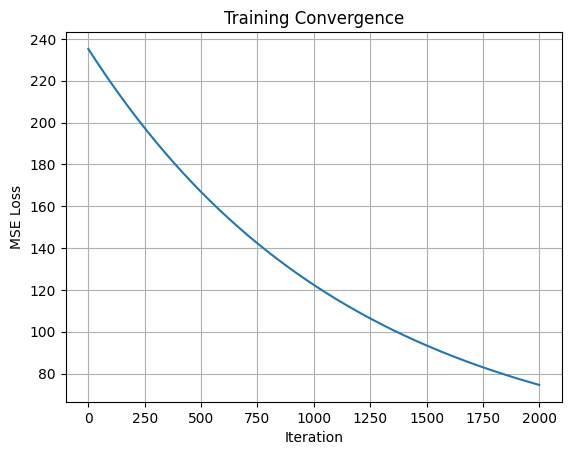

In [7]:
def gradient_descent(X, L, lr, epochs):
    w = np.zeros(X.shape[1])
    b = 0.0
    loss_history = []

    for _ in range(epochs):
        dw, db = compute_gradients(X, L, w, b)

        w -= lr * dw
        b -= lr * db

        loss_history.append(mse_loss(X, L, w, b))

    return w, b, loss_history


w, b, loss = gradient_descent(X, L, lr=1e-12, epochs=2000)

plt.figure()
plt.plot(loss)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Training Convergence")
plt.grid(True)
plt.show()


## 7. Feature selection experiment 

To evaluate the importance of nonlinear and interaction features, we compare multiple models with increasing complexity.

This experiment illustrates the trade-off between model expressiveness and simplicity, a central concern in both machine learning and enterprise system design.

M1: [M, T]
w: [7.86593718e-08 3.18231031e-04]
b: 3.690967373431193e-08
Final loss: 184.5890637060301


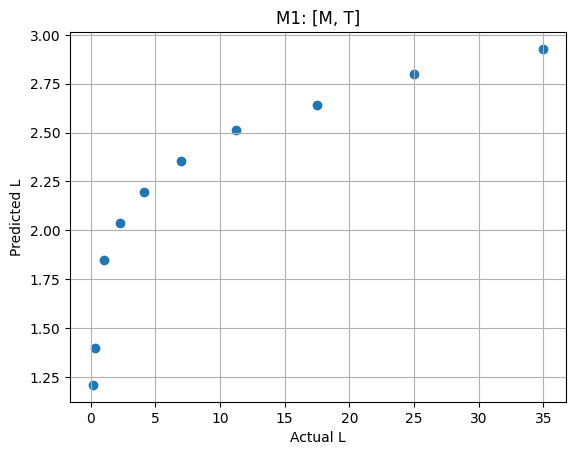

M2: [M, T, M^2]
w: [7.86593702e-08 3.18231024e-04 1.70225488e-07]
b: 3.690967289742962e-08
Final loss: 184.58905126282158


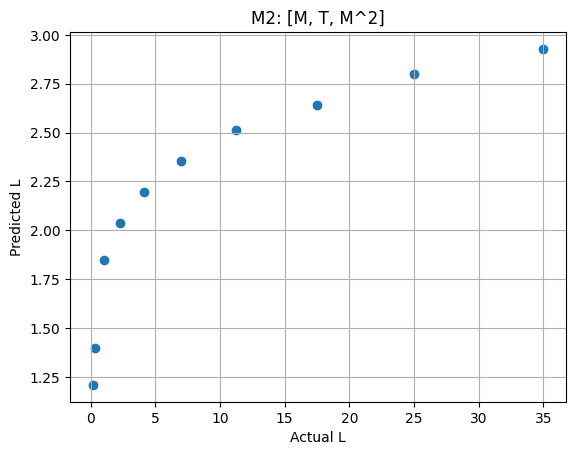

M3: [M, T, M^2, M*T]
w: [5.66446960e-08 2.23948210e-04 1.27016304e-07 5.03021468e-04]
b: 2.4926076036579934e-08
Final loss: 74.58847860933786


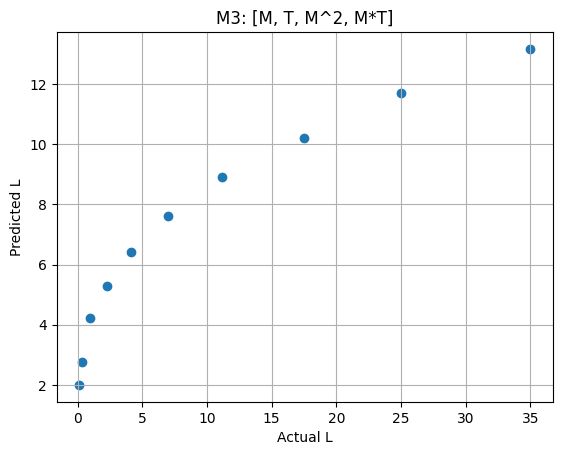

In [8]:
def run_model(feature_indices, label):
    X_sub = X[:, feature_indices]
    w, b, loss = gradient_descent(X_sub, L, lr=1e-12, epochs=2000)
    print(f"{label}")
    print("w:", w)
    print("b:", b)
    print("Final loss:", loss[-1])

    y_hat = predict(X_sub, w, b)

    plt.figure()
    plt.scatter(L, y_hat)
    plt.xlabel("Actual L")
    plt.ylabel("Predicted L")
    plt.title(label)
    plt.grid(True)
    plt.show()

run_model([0, 1], "M1: [M, T]")
run_model([0, 1, 2], "M2: [M, T, M^2]")
run_model([0, 1, 2, 3], "M3: [M, T, M^2, M*T]")


## 8. Cost vs interaction coefficient

This experiment isolates the interaction term and evaluates its impact on the cost function.

By varying the interaction coefficient while keeping all other parameters fixed, we assess whether the interaction contributes meaningfully to the model's predictive power.

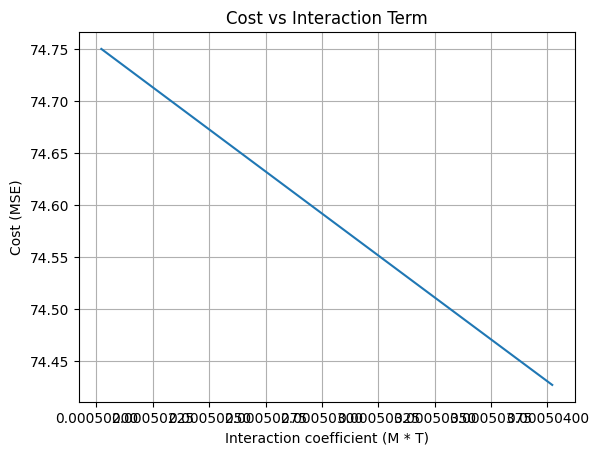

In [9]:
w_full, b_full, _ = gradient_descent(X, L, lr=1e-12, epochs=2000)

w_mt_values = np.linspace(w_full[3] - 1e-6, w_full[3] + 1e-6, 100)
costs = []

for w_mt in w_mt_values:
    w_temp = w_full.copy()
    w_temp[3] = w_mt
    costs.append(mse_loss(X, L, w_temp, b_full))

plt.figure()
plt.plot(w_mt_values, costs)
plt.xlabel("Interaction coefficient (M * T)")
plt.ylabel("Cost (MSE)")
plt.title("Cost vs Interaction Term")
plt.grid(True)
plt.show()


## 9. Inference demo (MANDATORY)

A trained regression model can be used as an inference component in a larger intelligent system.

Here, we test the model on a previously unseen star to verify whether the prediction is physically reasonable.

In [10]:
M_new = 1.3
T_new = 6600

X_new = np.array([[M_new, T_new, M_new**2, M_new * T_new]])

L_pred = predict(X_new, w_full, b_full)
print("Predicted luminosity:", L_pred[0])


Predicted luminosity: 5.793982693337595
